In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Disease and symptoms dataset.csv')

In [3]:
print("Shape: ",df.shape)
print ("\n First 5 rows: ")
df.head()

Shape:  (246945, 378)

 First 5 rows: 


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
print("Number of unique diseases :", df['diseases'].nunique())

Number of unique diseases : 773


In [5]:
print("Diseases value counts:")
df['diseases'].value_counts()

Diseases value counts:


diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
                                  ... 
foreign body in the nose             1
thalassemia                          1
open wound of the head               1
rocky mountain spotted fever         1
kaposi sarcoma                       1
Name: count, Length: 773, dtype: int64

In [6]:
# How many diseases have very few records?
counts = df['diseases'].value_counts()

print("Diseases with only 1 record:", (counts == 1).sum())
print("Diseases with less than 10 records:", (counts < 10).sum())
print("Diseases with less than 100 records:", (counts < 100).sum())

Diseases with only 1 record: 19
Diseases with less than 10 records: 96
Diseases with less than 100 records: 330


In [7]:
# Keep only diseases with 100 or more records
counts = df['diseases'].value_counts()
valid_diseases = counts[counts >= 100].index

df_cleaned = df[df['diseases'].isin(valid_diseases)]

print("Original shape:", df.shape)
print("Cleaned shape:", df_cleaned.shape)
print("Diseases remaining:", df_cleaned['diseases'].nunique())

Original shape: (246945, 378)
Cleaned shape: (236619, 378)
Diseases remaining: 443


In [8]:
print("Total missing values:", df_cleaned.isnull().sum().sum())

Total missing values: 0


In [9]:
# Check for duplicate rows
print("Total duplicate rows:", df_cleaned.duplicated().sum()) 

Total duplicate rows: 51028


In [10]:
# Check if duplicates are within same disease or across different diseases
dupes = df_cleaned[df_cleaned.duplicated(keep=False)]

print("Total rows involved in duplication:", len(dupes))
print("\nSample of duplicated rows (first 10):")
dupes.sort_values('diseases').head(10)[['diseases']]

Total rows involved in duplication: 85597

Sample of duplicated rows (first 10):


,diseases
235946,abdominal aortic aneurysm
235944,abdominal aortic aneurysm
235945,abdominal aortic aneurysm
235948,abdominal aortic aneurysm
235949,abdominal aortic aneurysm
235950,abdominal aortic aneurysm
235952,abdominal aortic aneurysm
235953,abdominal aortic aneurysm
235954,abdominal aortic aneurysm
235955,abdominal aortic aneurysm


In [11]:
# Check if any duplicates exist across DIFFERENT diseases
cross_disease_dupes = df_cleaned[df_cleaned.duplicated(subset=df_cleaned.columns.difference(['diseases']), keep=False)]

same = cross_disease_dupes.groupby(list(df_cleaned.columns.difference(['diseases'])))['diseases'].nunique()
print("Symptom patterns mapping to multiple diseases:", (same > 1).sum())

Symptom patterns mapping to multiple diseases: 12193


In [12]:
# Find symptom columns only (everything except diseases)
symptom_cols = df_cleaned.columns.difference(['diseases'])

# Find ambiguous patterns (same symptoms, different diseases)
ambiguous = df_cleaned.groupby(list(symptom_cols))['diseases'].nunique()
ambiguous_patterns = ambiguous[ambiguous > 1].index

# Remove ambiguous rows
df_cleaned = df_cleaned[~df_cleaned.set_index(list(symptom_cols)).index.isin(ambiguous_patterns)]

print("Shape after removing ambiguous rows:", df_cleaned.shape)

# Now remove remaining duplicates (same disease, same symptoms)
df_cleaned = df_cleaned.drop_duplicates()

print("Shape after removing all duplicates:", df_cleaned.shape)
print("Diseases remaining:", df_cleaned['diseases'].nunique())

Shape after removing ambiguous rows: (199412, 378)
Shape after removing all duplicates: (154684, 378)
Diseases remaining: 442


In [13]:
# Verify our cleaned dataset
print("Final shape:", df_cleaned.shape)
print("Any missing values?", df_cleaned.isnull().sum().sum())
print("Any duplicates?", df_cleaned.duplicated().sum())
print("Diseases count:", df_cleaned['diseases'].nunique())
print("\nDisease record distribution:")
df_cleaned['diseases'].value_counts().describe()

Final shape: (154684, 378)
Any missing values? 0
Any duplicates? 0
Diseases count: 442

Disease record distribution:


count     442.000000
mean      349.963801
std       312.040688
min        11.000000
25%       104.250000
50%       255.500000
75%       497.750000
max      1190.000000
Name: count, dtype: float64

In [14]:
# Re-apply the 100 record minimum threshold
counts = df_cleaned['diseases'].value_counts()
valid_diseases = counts[counts >= 100].index
df_cleaned = df_cleaned[df_cleaned['diseases'].isin(valid_diseases)]

print("Final shape:", df_cleaned.shape)
print("Diseases remaining:", df_cleaned['diseases'].nunique())
print("\nDistribution after re-filtering:")
df_cleaned['diseases'].value_counts().describe()

Final shape: (148755, 378)
Diseases remaining: 333

Distribution after re-filtering:


count     333.000000
mean      446.711712
std       301.852036
min       100.000000
25%       197.000000
50%       374.000000
75%       677.000000
max      1190.000000
Name: count, dtype: float64

In [15]:
df_cleaned.to_csv('cleaned dataset.csv', index=False)
print("Saved successfully!")

Saved successfully!


In [16]:
# Sum each symptom column (since values are 0/1, sum = total occurrences)
symptom_cols = df_cleaned.columns.difference(['diseases'])
symptom_counts = df_cleaned[symptom_cols].sum().sort_values(ascending=False)

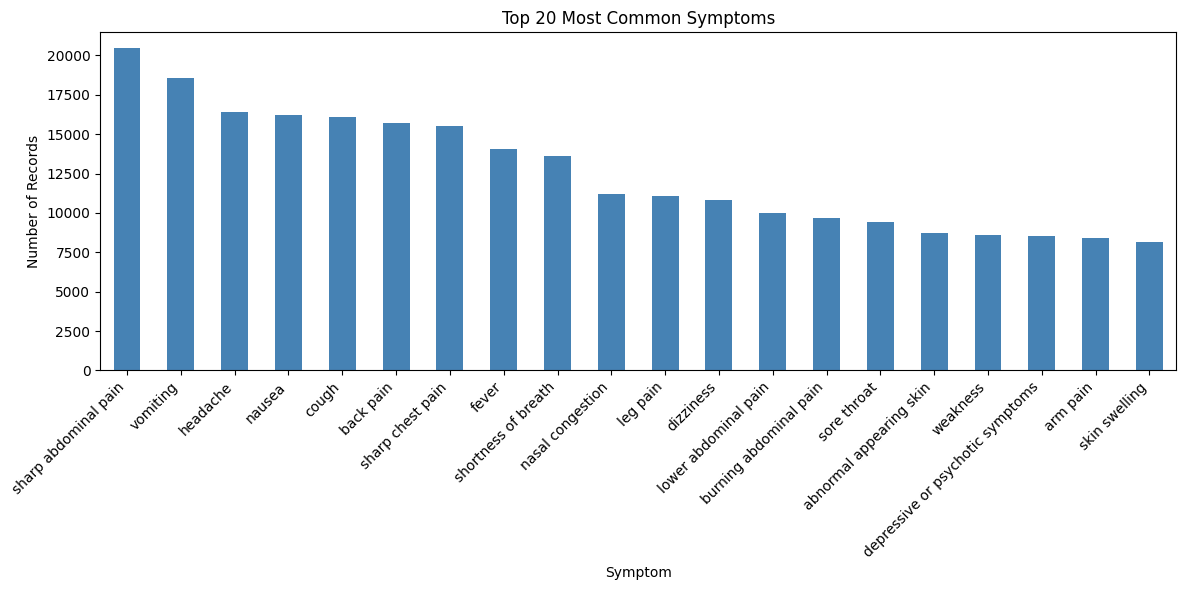

In [17]:
# Plot top 20 most common symptoms
plt.figure(figsize=(12, 6))
symptom_counts.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Most Common Symptoms')
plt.xlabel('Symptom')
plt.ylabel('Number of Records')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

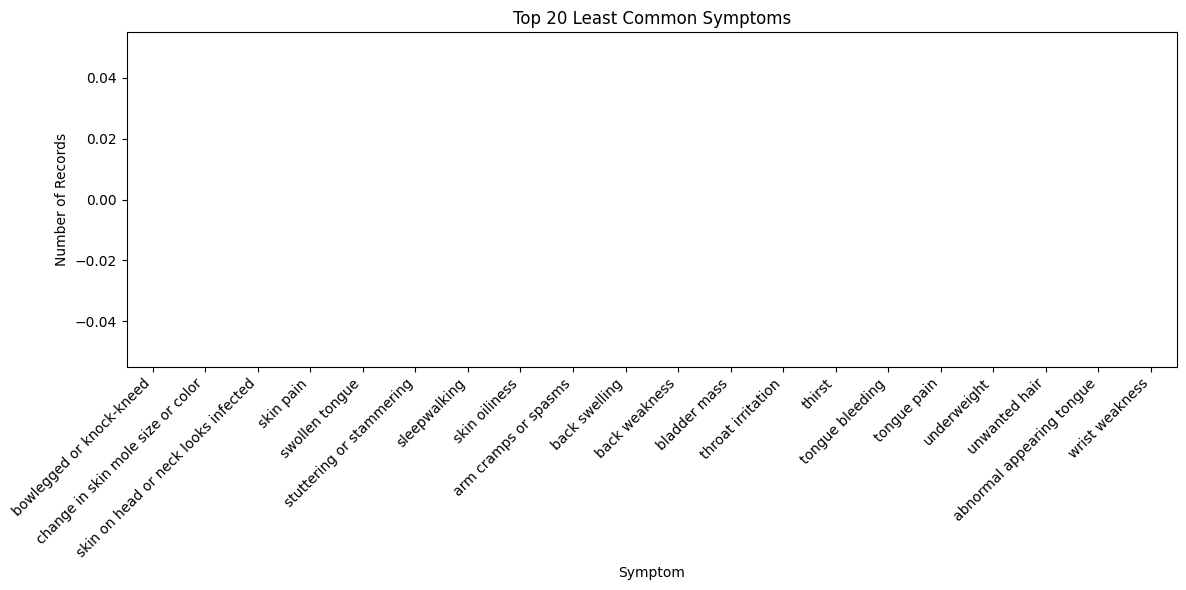

In [18]:
# Bottom 20 least common symptoms
plt.figure(figsize=(12, 6))
symptom_counts.tail(20).plot(kind='bar', color='salmon')
plt.title('Top 20 Least Common Symptoms')
plt.xlabel('Symptom')
plt.ylabel('Number of Records')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
# Find all symptoms with zero occurrences
zero_symptoms = symptom_counts[symptom_counts == 0]
print("Total symptoms with zero occurrences:", len(zero_symptoms))
print("\nSymptoms to be removed:")
print(zero_symptoms.index.tolist())

Total symptoms with zero occurrences: 86

Symptoms to be removed:
['abnormal size or shape of ear', 'low back swelling', 'foot or toe cramps or spasms', 'lip sore', 'low back cramps or spasms', 'low back stiffness or tightness', 'knee cramps or spasms', 'leg lump or mass', 'hand or finger cramps or spasms', 'hip lump or mass', 'hip swelling', 'joint stiffness or tightness', 'itching of scrotum', 'jaw pain', 'vaginal bleeding after menopause', 'ankle weakness', 'ankle stiffness or tightness', 'vulvar sore', 'hip weakness', 'incontinence of stool', 'infant spitting up', 'infrequent menstruation', 'neck weakness', 'muscle weakness', 'nailbiting', 'muscle swelling', 'muscle stiffness or tightness', 'mass on vulva', 'lump over jaw', 'mass on ear', 'low back weakness', 'foot or toe lump or mass', 'flushing', 'elbow stiffness or tightness', 'elbow cramps or spasms', 'disturbance of smell or taste', 'problems with shape or size of breast', 'elbow lump or mass', 'feeling cold', 'feeling hot', '

In [20]:
# Remove zero-occurrence symptom columns
df_cleaned = df_cleaned.drop(columns=zero_symptoms.index)

print("Shape before removing zero columns:", df_cleaned.shape)
print("Columns removed:", len(zero_symptoms))
print("New shape:", df_cleaned.shape)

Shape before removing zero columns: (148755, 292)
Columns removed: 86
New shape: (148755, 292)


In [21]:
print("Current shape:", df_cleaned.shape)
print("Any zero-variance columns remaining?")
symptom_cols = df_cleaned.columns.difference(['diseases'])
zero_check = df_cleaned[symptom_cols].sum()
print("Zero columns remaining:", (zero_check == 0).sum())

Current shape: (148755, 292)
Any zero-variance columns remaining?
Zero columns remaining: 0


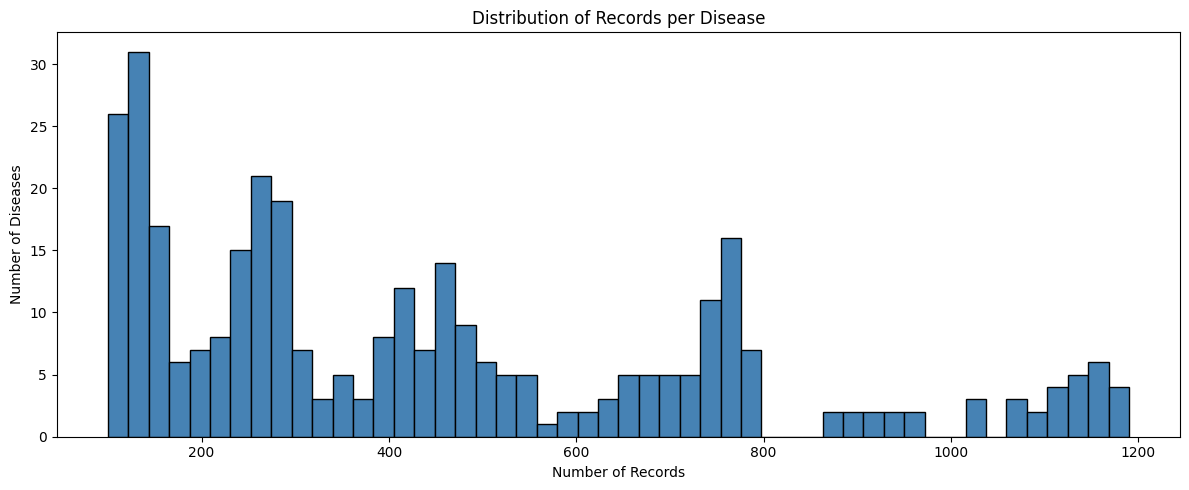

In [25]:
plt.figure(figsize=(12, 5))
df_cleaned['diseases'].value_counts().plot(kind='hist', bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Records per Disease')
plt.xlabel('Number of Records')
plt.ylabel('Number of Diseases')
plt.tight_layout()

# Save graph
plt.savefig('distribution_per_disease.png', dpi=300, bbox_inches='tight')

plt.show()

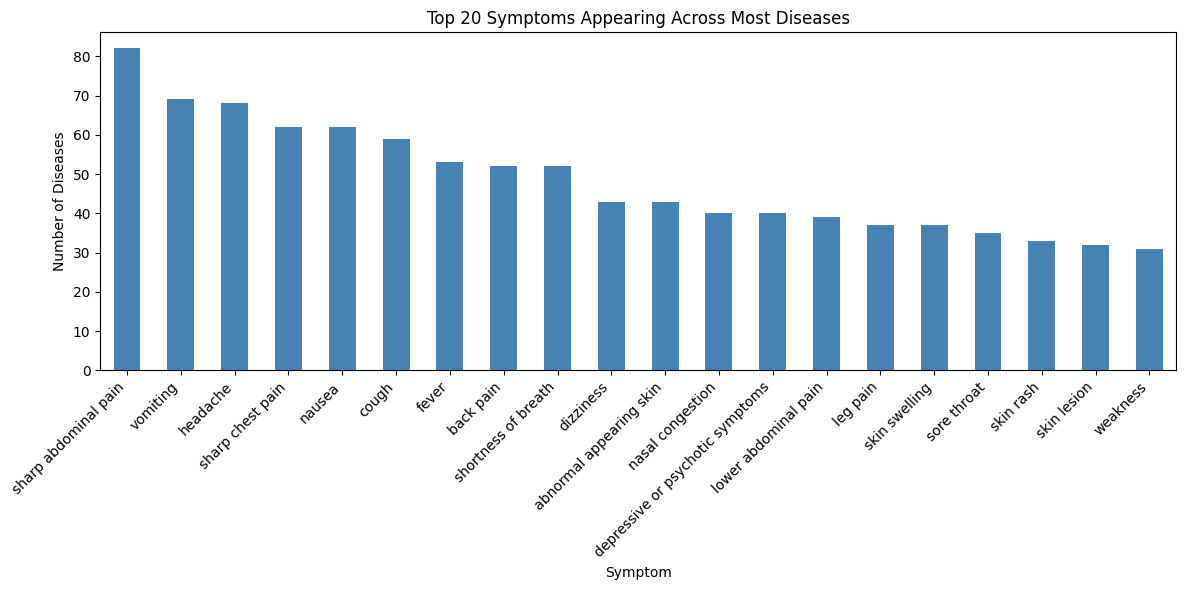

In [27]:
# Calculate how many UNIQUE diseases each symptom appears in
symptom_cols = df_cleaned.columns.difference(['diseases'])

symptom_disease_count = {}
for symptom in symptom_cols:
    # Get diseases where this symptom = 1
    diseases_with_symptom = df_cleaned[df_cleaned[symptom] == 1]['diseases'].nunique()
    symptom_disease_count[symptom] = diseases_with_symptom

symptom_disease_series = pd.Series(symptom_disease_count).sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(12, 6))
symptom_disease_series.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Symptoms Appearing Across Most Diseases')
plt.xlabel('Symptom')
plt.ylabel('Number of Diseases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save graph
plt.savefig('Symptoms Appearing Across Most Diseases.png', dpi=300, bbox_inches='tight')
plt.show()

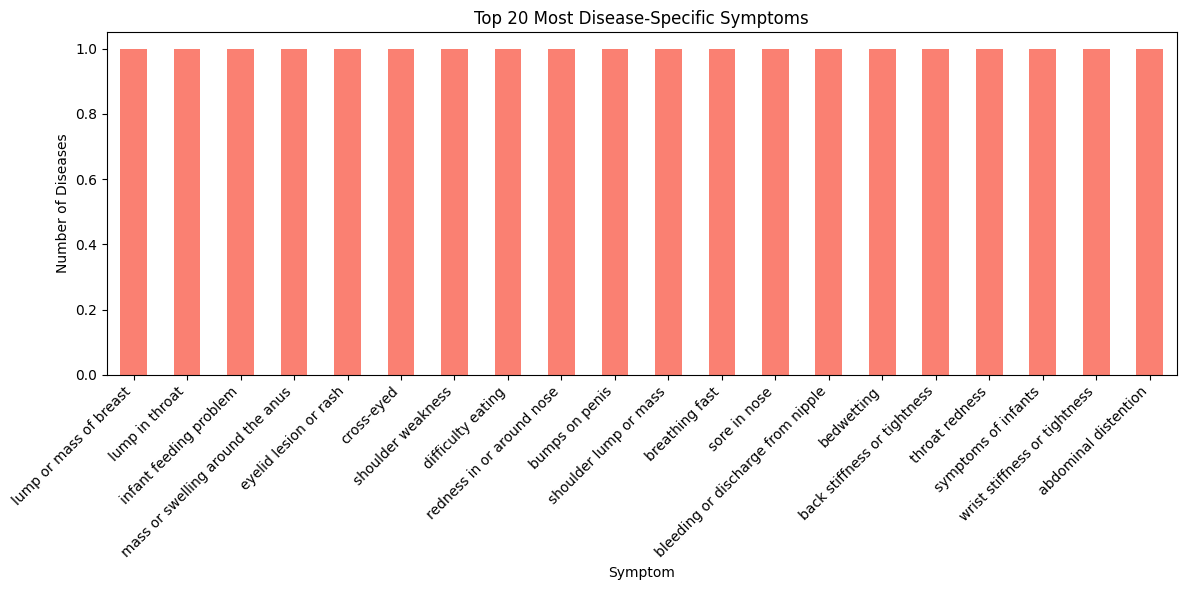

In [28]:
# Bottom 20 - symptoms appearing in fewest diseases
plt.figure(figsize=(12, 6))
symptom_disease_series.tail(20).plot(kind='bar', color='salmon')
plt.title('Top 20 Most Disease-Specific Symptoms')
plt.xlabel('Symptom')
plt.ylabel('Number of Diseases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save graph
plt.savefig('Most Disease-Specific Symptoms.png', dpi=300, bbox_inches='tight')
plt.show()

# Machine Learning Implement

In [29]:
# Split into features and target
X = df_cleaned.drop(columns=['diseases'])
y = df_cleaned['diseases']

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)
print("\nSample of y:")
print(y.value_counts().head())

Features shape (X): (148755, 291)
Target shape (y): (148755,)

Sample of y:
diseases
hypoglycemia                     1190
obstructive sleep apnea (osa)    1182
bursitis                         1179
concussion                       1175
liver disease                    1166
Name: count, dtype: int64


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # ensures same split every time you run
    stratify=y          # maintains disease distribution in both splits
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining diseases distribution sample:")
y_train.value_counts().head()

Training set size: (119004, 291)
Test set size: (29751, 291)

Training diseases distribution sample:


diseases
hypoglycemia                     952
obstructive sleep apnea (osa)    945
bursitis                         943
concussion                       940
liver disease                    933
Name: count, dtype: int64

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Train the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=1             # single core to save memory
)

print("Training started...")
rf_model.fit(X_train, y_train)
print("Training complete!")

# Predict in batches to avoid memory error
batch_size = 1000
y_pred = []

for i in range(0, len(X_test), batch_size):
    batch = X_test.iloc[i:i+batch_size]
    y_pred.extend(rf_model.predict(batch))

y_pred = np.array(y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Training started...
Training complete!

Test Accuracy: 0.9475 (94.75%)


In [54]:
# Get all unique diseases from cleaned dataset
diseases = sorted(df_cleaned['diseases'].unique().tolist())
print(f"Total unique diseases: {len(diseases)}")

# Create a simple CSV with just the disease column
import pandas as pd
disease_df = pd.DataFrame({'disease': diseases})
disease_df.to_csv('unique_diseases.csv', index=False)

print("CSV saved successfully!")
print("\nFirst 5 diseases:")
print(disease_df.head())

Total unique diseases: 333
CSV saved successfully!

First 5 diseases:
                  disease
0        abdominal hernia
1         abscess of nose
2  abscess of the pharynx
3                    acne
4       actinic keratosis
